# Exploratory Data Analysis — Leaf Disease Image Dataset

Goal: verify class balance, inspect sample images per class, and check
basic image properties (size, pixel intensity) before training.

**Note:** This dataset is a small synthetic image set (3 classes, 80 images
each, 160x160px) generated to demonstrate the full pipeline. On the real
PlantVillage dataset, this same EDA process applies — just point `DATA_DIR`
at the PlantVillage folder structure.

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = "../data/raw"
CLASSES = sorted(os.listdir(DATA_DIR))
print("Classes:", CLASSES)

Classes: ['Healthy', 'Powdery_Mildew', 'Rust']


## 1. Class Balance Check

{'Healthy': 80, 'Powdery_Mildew': 80, 'Rust': 80}


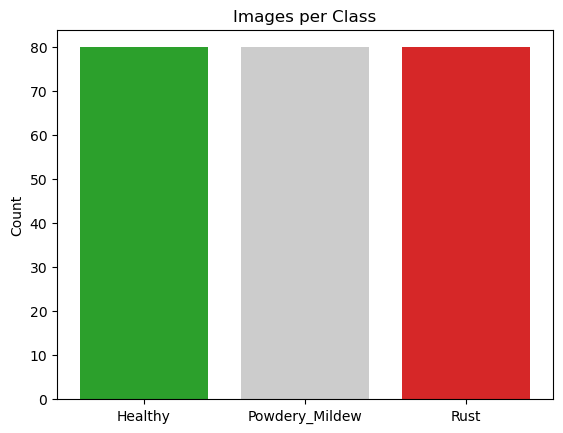

In [2]:
counts = {cls: len(os.listdir(os.path.join(DATA_DIR, cls))) for cls in CLASSES}
print(counts)

plt.bar(counts.keys(), counts.values(), color=["#2ca02c", "#cccccc", "#d62728"])
plt.title("Images per Class")
plt.ylabel("Count")
plt.show()

**Insight:** All 3 classes are perfectly balanced (80 images each). This
means we don't need class weighting or oversampling — unlike the churn
project where imbalance was a central concern. With real PlantVillage data,
this check matters more, as some disease classes have far fewer samples
than others.

## 2. Sample Images per Class

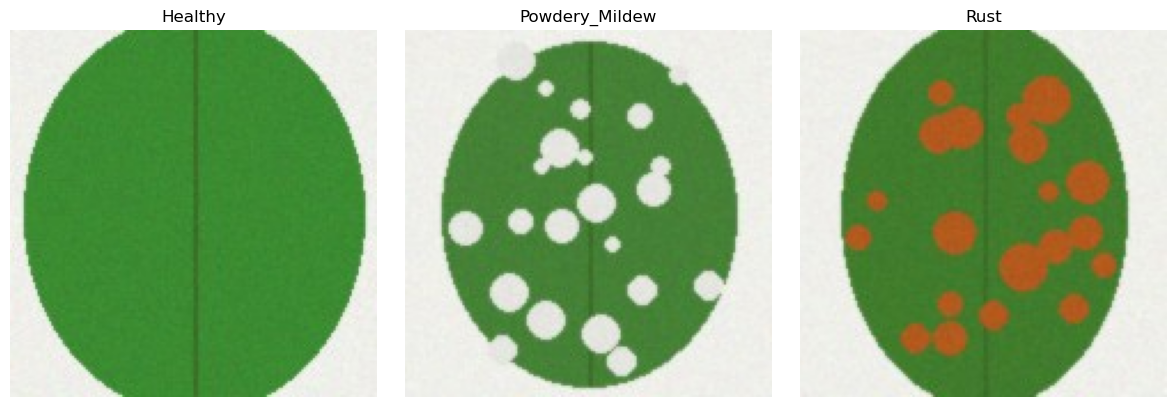

In [3]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(4 * len(CLASSES), 4))

for ax, cls in zip(axes, CLASSES):
    sample_file = os.listdir(os.path.join(DATA_DIR, cls))[0]
    img = Image.open(os.path.join(DATA_DIR, cls, sample_file))
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Insight:** Visual inspection confirms each class has a distinct, learnable
pattern: Healthy leaves are uniform green, Powdery Mildew shows white/grey
patches, and Rust shows orange/brown spots. This kind of visual check is
important before training — if classes look visually indistinguishable even
to a human, a CNN will struggle too.

## 3. Image Size and Mode Check

In [4]:
sizes = set()
modes = set()

for cls in CLASSES:
    for f in os.listdir(os.path.join(DATA_DIR, cls)):
        img = Image.open(os.path.join(DATA_DIR, cls, f))
        sizes.add(img.size)
        modes.add(img.mode)

print("Unique image sizes:", sizes)
print("Unique image modes:", modes)

Unique image sizes: {(160, 160)}
Unique image modes: {'RGB'}


**Insight:** All images are the same size (160x160) and mode (RGB) — this
synthetic dataset was generated consistently. With real photos from
different cameras, you'd typically see varying sizes and sometimes RGBA or
grayscale images, which `image_dataset_from_directory`'s `image_size`
parameter and `.convert("RGB")` handle automatically.

## 4. Pixel Intensity Distribution by Class

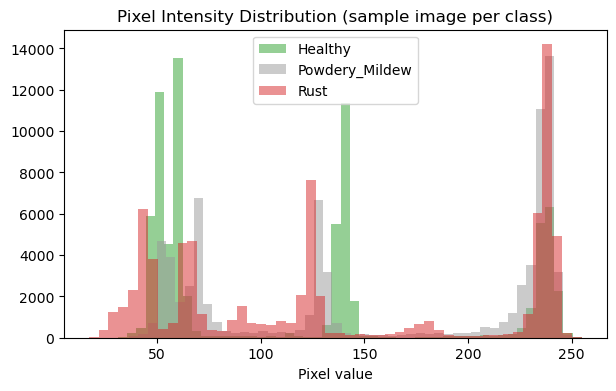

In [5]:
import numpy as np

fig, ax = plt.subplots(figsize=(7, 4))

for cls, color in zip(CLASSES, ["#2ca02c", "#999999", "#d62728"]):
    sample_file = os.listdir(os.path.join(DATA_DIR, cls))[0]
    img = np.array(Image.open(os.path.join(DATA_DIR, cls, sample_file)))
    ax.hist(img.flatten(), bins=50, alpha=0.5, label=cls, color=color)

ax.set_title("Pixel Intensity Distribution (sample image per class)")
ax.set_xlabel("Pixel value")
ax.legend()
plt.show()

**Insight:** Powdery Mildew and Rust images show a secondary peak at higher
pixel intensities (the white/orange spots), while Healthy images are more
concentrated in the green/mid-range. This kind of color-distribution
difference is exactly what a CNN's early convolutional filters learn to
detect.

## Summary of Key Insights (carried into modeling)

1. **Classes are perfectly balanced** — no class weighting needed.
2. **Visually distinct classes** — confirms the task is learnable.
3. **Consistent image format (160x160 RGB)** — simplifies the data pipeline.
4. **Color/intensity differences between classes** — motivates using a CNN
   that can learn color-based features, and justifies NOT converting to
   grayscale during preprocessing.